<a href="https://colab.research.google.com/github/adedamolabalogun959-hub/project_advertising/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
filepath = '/content/drive/MyDrive/advertise.csv'
df = pd.read_csv(filepath)

In [19]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [20]:
df.shape

(4572, 4)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [22]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [23]:
df.isnull().sum()

,0
TV,10
Radio,4
Social_Media,6
Sales,6


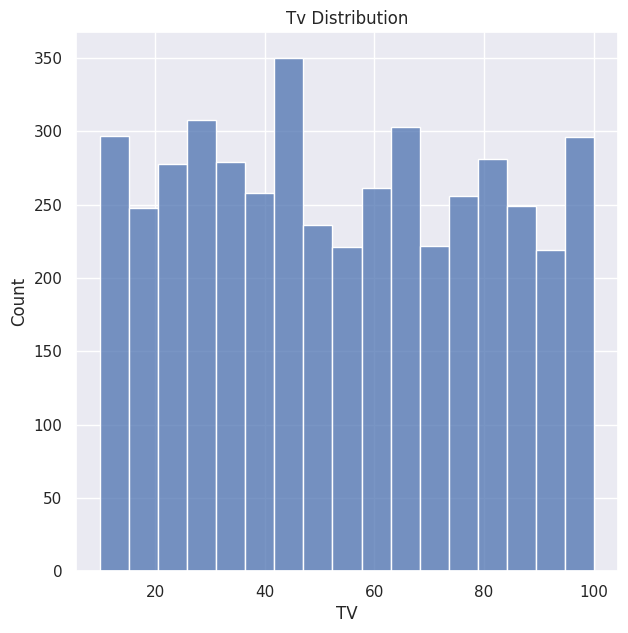

In [24]:
sns.set()
plt.figure(figsize=(7,7))
sns.histplot(df['TV'])
plt.title('Tv Distribution')
plt.show()

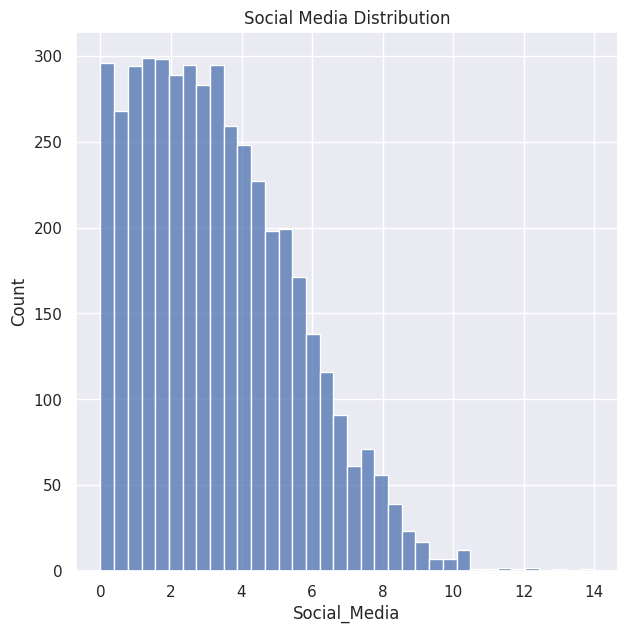

In [25]:
plt.figure(figsize=(7,7))
sns.histplot(df['Social_Media'])
plt.title('Social Media Distribution')
plt.show()

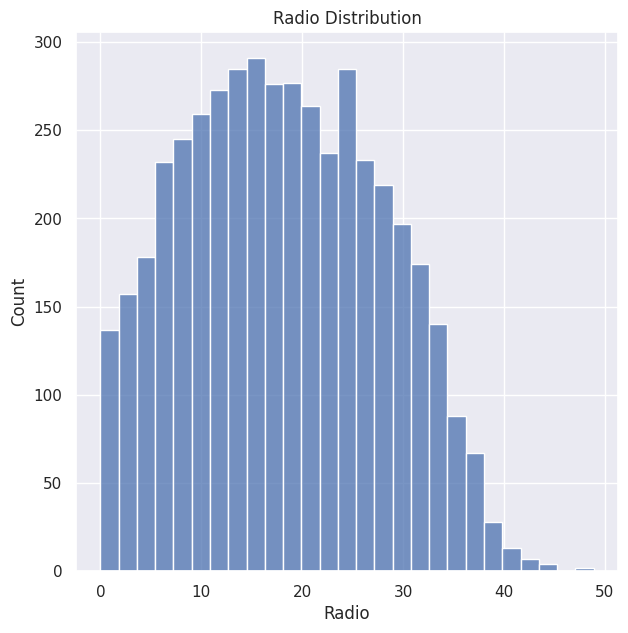

In [26]:
plt.figure(figsize=(7,7))
sns.histplot(df['Radio'])
plt.title('Radio Distribution')
plt.show()

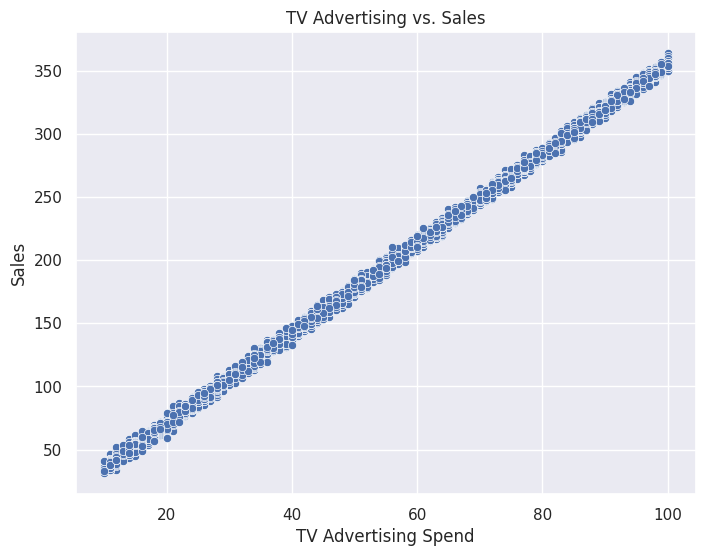

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs. Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

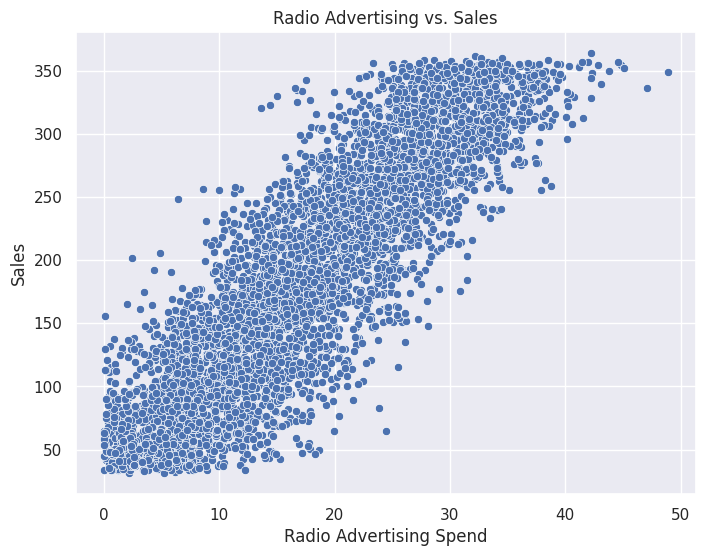

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs. Sales')
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

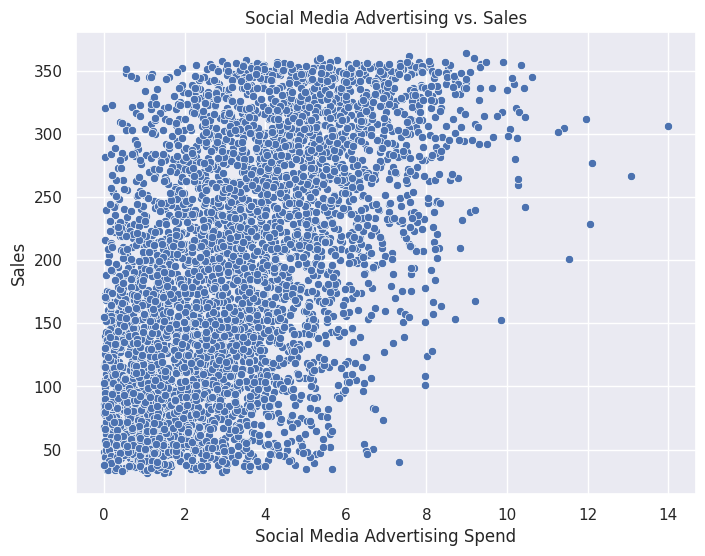

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Social_Media', y='Sales', data=df)
plt.title('Social Media Advertising vs. Sales')
plt.xlabel('Social Media Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

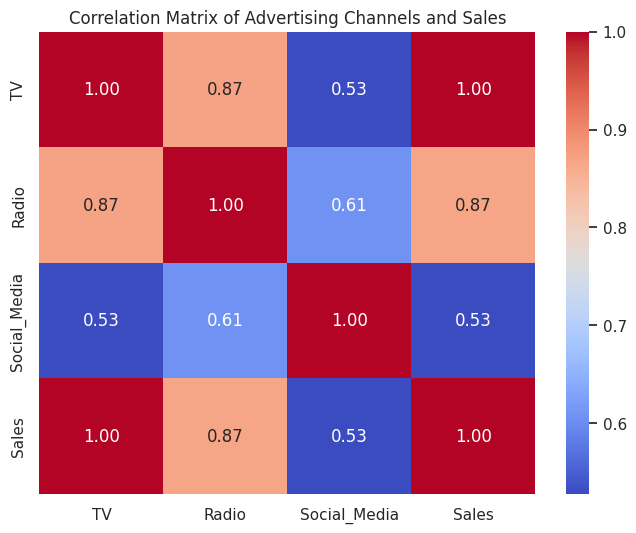

In [30]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advertising Channels and Sales')
plt.show()

In [34]:
import statsmodels.api as sm

# Create a temporary DataFrame with only the relevant columns and drop rows with NaNs
temp_df = df[['TV', 'Sales']].dropna()

X = temp_df['TV']
y = temp_df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:23:21   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1263      0.101     -1.257      0.2

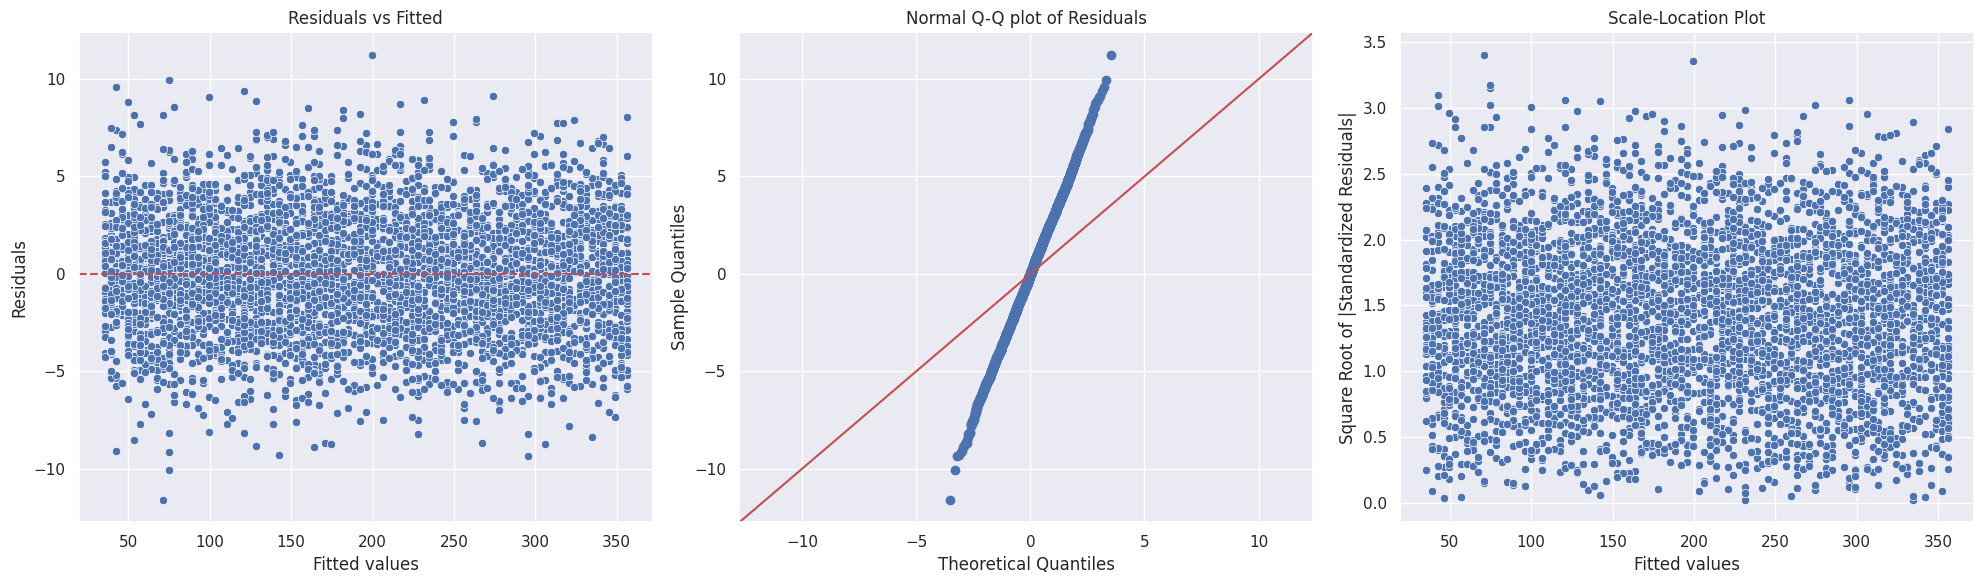

In [35]:
import statsmodels.api as sm
import scipy.stats as stats

# Get predictions and residuals
y_pred = model.predict(X)
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Residuals vs Fitted values (Linearity and Homoscedasticity)
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Plot 2: Normal Q-Q plot (Normality of Residuals)
sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Normal Q-Q plot of Residuals')

# Plot 3: Scale-Location plot (Homoscedasticity)
sqrt_abs_residuals = np.sqrt(np.abs(residuals))
sns.scatterplot(x=y_pred, y=sqrt_abs_residuals, ax=axes[2])
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Square Root of |Standardized Residuals|')
axes[2].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()